# 02 — Engagement Index
Combine `JobInvolvement`, `JobSatisfaction`, `EnvironmentSatisfaction`, and `RelationshipSatisfaction` into a single, normalized (rescaled to a common 0–1 range) **Engagement Index** per employee.

In [1]:
import pandas as pd
df = pd.read_csv('../data/processed/cleaned_data.csv')
engagement_cols = ['JobInvolvement', 'JobSatisfaction',
                    'EnvironmentSatisfaction', 'RelationshipSatisfaction']
df[engagement_cols].describe()

,JobInvolvement,JobSatisfaction,EnvironmentSatisfaction,RelationshipSatisfaction
count,1470.000000,1470.000000,1470.000000,1470.000000
mean,2.729932,2.728571,2.721769,2.712245
std,0.711561,1.102846,1.093082,1.081209
min,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000,2.000000
50%,3.000000,3.000000,3.000000,3.000000
75%,3.000000,4.000000,4.000000,4.000000
max,4.000000,4.000000,4.000000,4.000000


## Build the composite score
Each of the 4 columns is on the same 1–4 scale already, so we take a simple mean (equal weighting) and then rescale (normalize) it to 0–1 so it reads like a percentage-style index.

In [2]:
df['EngagementRaw'] = df[engagement_cols].mean(axis=1)

min_raw, max_raw = df['EngagementRaw'].min(), df['EngagementRaw'].max()
df['EngagementIndex'] = (df['EngagementRaw'] - min_raw) / (max_raw - min_raw)
df[['EngagementRaw', 'EngagementIndex']].describe()

,EngagementRaw,EngagementIndex
count,1470.000000,1470.000000
mean,2.723129,0.535683
std,0.504026,0.183282
min,1.250000,0.000000
25%,2.500000,0.454545
50%,2.750000,0.545455
75%,3.000000,0.636364
max,4.000000,1.000000


## Engagement tiers
Bucket the continuous index into Low / Medium / High bands so the dashboard can filter and highlight groups easily.

In [3]:
def engagement_tier(x):
    if x < 0.34:
        return 'Low'
    elif x < 0.67:
        return 'Medium'
    else:
        return 'High'

df['EngagementTier'] = df['EngagementIndex'].apply(engagement_tier)
df['EngagementTier'].value_counts()

EngagementTier
Medium    972
High      322
Low       176
Name: count, dtype: int64

## Sanity check: distribution

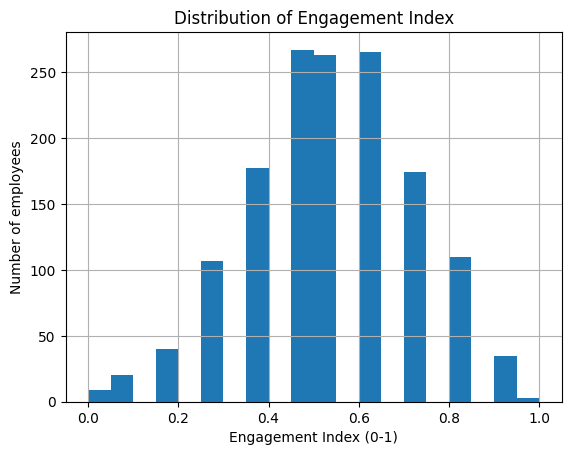

In [4]:
import matplotlib.pyplot as plt
df['EngagementIndex'].hist(bins=20)
plt.title('Distribution of Engagement Index')
plt.xlabel('Engagement Index (0-1)')
plt.ylabel('Number of employees')
plt.show()

## Save

In [5]:
df.to_csv('../data/processed/engagement_scored.csv', index=False)
print('Saved -> ../data/processed/engagement_scored.csv')

Saved -> ../data/processed/engagement_scored.csv
